## RTBRISCOE STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

rtbriscoe=pd.read_csv('../stock_data/rtbriscoe.csv') ## so it can be small letter. This is cool.
rtbriscoe=rtbriscoe.drop(columns=['high_price','low_price'])
rtbriscoe.rename(columns={'trade_date':'date'},inplace=True)
rtbriscoe['date']=pd.to_datetime(rtbriscoe['date'])
rtbriscoe['month']=rtbriscoe['date'].dt.month
rtbriscoe['quarter']=rtbriscoe['date'].dt.quarter
rtbriscoe['year']=rtbriscoe['date'].dt.year

rtbriscoe

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42855,RTBRISCOE,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43415,RTBRISCOE,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43525,RTBRISCOE,2017-01-05,0.50,0.50,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43635,RTBRISCOE,2017-01-06,0.50,0.50,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43725,RTBRISCOE,2017-01-09,0.50,0.50,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298125,RTBRISCOE,2026-07-13,12.10,12.10,1315068,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298563,RTBRISCOE,2026-07-14,13.15,13.15,3094917,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299001,RTBRISCOE,2026-07-15,12.75,12.75,547366,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299439,RTBRISCOE,2026-07-16,12.75,12.75,584117,2026-07-16T15:10:03.113936+00:00,7,3,2026


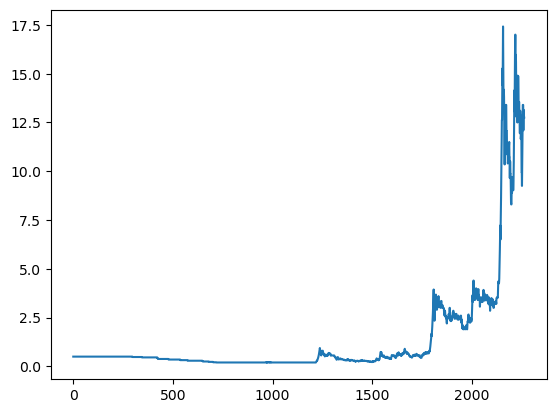

In [2]:
import matplotlib.pyplot as plt

plt.plot(rtbriscoe['close_price'])
plt.show()

In [3]:
rtbriscoe_end_month_df = (
    rtbriscoe
    .sort_values("date")
    .groupby(rtbriscoe["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

rtbriscoe_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45425,RTBRISCOE,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47248,RTBRISCOE,2017-02-28,0.50,0.50,887,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49364,RTBRISCOE,2017-03-31,0.50,0.50,1816,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51191,RTBRISCOE,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53114,RTBRISCOE,2017-05-31,0.50,0.50,500,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35362,RTBRISCOE,2026-03-31,9.65,9.65,3618668,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281188,RTBRISCOE,2026-04-30,10.64,10.64,969614,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284254,RTBRISCOE,2026-05-29,12.50,12.50,1252176,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294182,RTBRISCOE,2026-06-30,9.95,9.95,2263837,2026-06-30T15:10:03.08168+00:00,6,2,2026


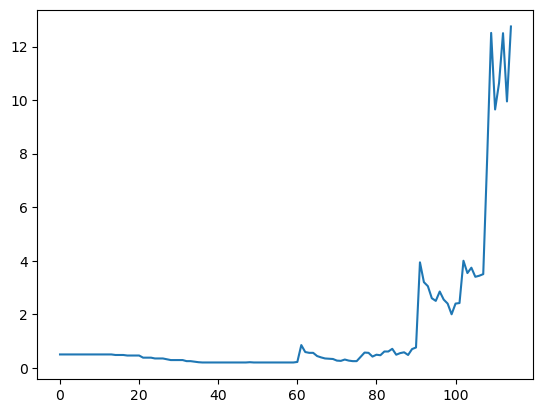

In [4]:
plt.plot(rtbriscoe_end_month_df['close_price'])
plt.show()

In [5]:
rtbriscoe_end_month_df['returns']=rtbriscoe_end_month_df['close_price'].pct_change()*100
rtbriscoe_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45425,RTBRISCOE,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47248,RTBRISCOE,2017-02-28,0.50,0.50,887,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49364,RTBRISCOE,2017-03-31,0.50,0.50,1816,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51191,RTBRISCOE,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53114,RTBRISCOE,2017-05-31,0.50,0.50,500,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35362,RTBRISCOE,2026-03-31,9.65,9.65,3618668,2026-03-31T15:00:02.085058+00:00,3,1,2026,-22.861711
111,281188,RTBRISCOE,2026-04-30,10.64,10.64,969614,2026-04-30T15:00:02.170664+00:00,4,2,2026,10.259067
112,284254,RTBRISCOE,2026-05-29,12.50,12.50,1252176,2026-05-29T15:00:02.455558+00:00,5,2,2026,17.481203
113,294182,RTBRISCOE,2026-06-30,9.95,9.95,2263837,2026-06-30T15:10:03.08168+00:00,6,2,2026,-20.400000


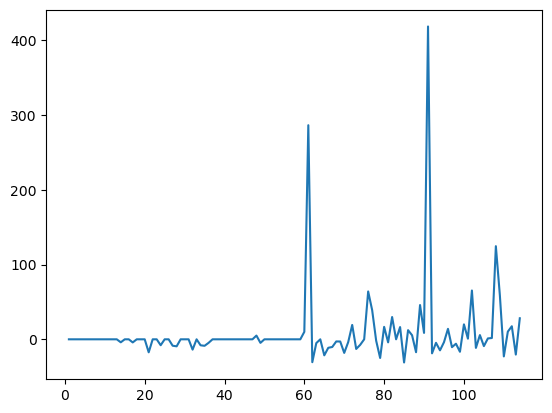

In [6]:
plt.plot(rtbriscoe_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(rtbriscoe_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-10.951887149073496, 8.75553978657563e-20, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 1085.322132627089)
stationary


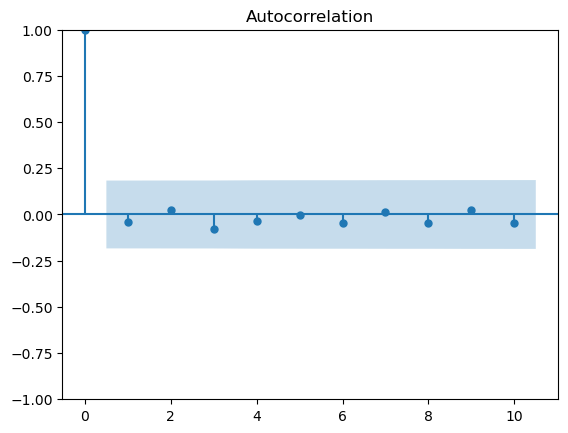

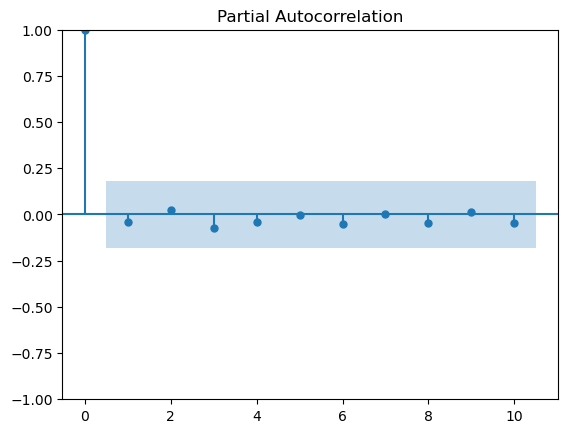

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(rtbriscoe_end_month_df['returns'].dropna(), lags=10)
plot_pacf(rtbriscoe_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=rtbriscoe_end_month_df['close_price'][:-10]
test=rtbriscoe_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -5.502953496501424]
[0, 0, 0, 0, 0, 1, -3.3681827794213435]
[0, 0, 0, 0, 0, 2, -2.8207606216710723]
[0, 0, 0, 0, 1, 0, -2.6186649425593806]
[0, 0, 0, 0, 1, 1, -2.319861013254386]
[0, 0, 0, 0, 1, 2, -2.3251128767715117]
[0, 0, 0, 0, 2, 0, -1.148108814297737]
[0, 0, 0, 0, 2, 1, -1.7275143328560918]
[0, 0, 0, 0, 2, 2, -1.9521419639286326]
[0, 0, 0, 1, 0, 0, -3.017828570299816]
[0, 0, 0, 1, 0, 1, -2.6693794343170096]
[0, 0, 0, 1, 0, 2, -2.733437830228285]
[0, 0, 0, 1, 1, 0, -2.3275605483233224]
[0, 0, 0, 1, 1, 1, -2.358360773565233]
[0, 0, 0, 1, 1, 2, -2.350969278346208]
[0, 0, 0, 1, 2, 0, -1.677002758056489]
[0, 0, 0, 1, 2, 1, -1.8150772141026272]
[0, 0, 0, 1, 2, 2, -1.907384863746635]
[0, 0, 0, 2, 0, 0, -2.742595801945605]
[0, 0, 0, 2, 0, 1, -2.725608681877218]
[0, 0, 0, 2, 0, 2, -2.7345918520036654]
[0, 0, 0, 2, 1, 0, -2.327646142586962]
[0, 0, 0, 2, 1, 1, -2.344725223568542]
[0, 0, 0, 2, 1, 2, -2.328559297106578]
[0, 0, 0, 2, 2, 0, -1.8963634130903215]
[0, 0, 0, 2, 2

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
664,2,2,0,1,2,1,-4.752572e+06
411,1,2,0,0,2,0,-4.066291e+01
654,2,2,0,0,2,0,-3.579643e+01
420,1,2,0,1,2,0,-1.801101e+01
412,1,2,0,0,2,1,-1.714901e+01
...,...,...,...,...,...,...,...
186,0,2,0,2,2,0,2.770960e-02
170,0,2,0,0,2,2,5.646133e-02
165,0,2,0,0,1,0,6.791790e-01
177,0,2,0,1,2,0,6.810267e-01


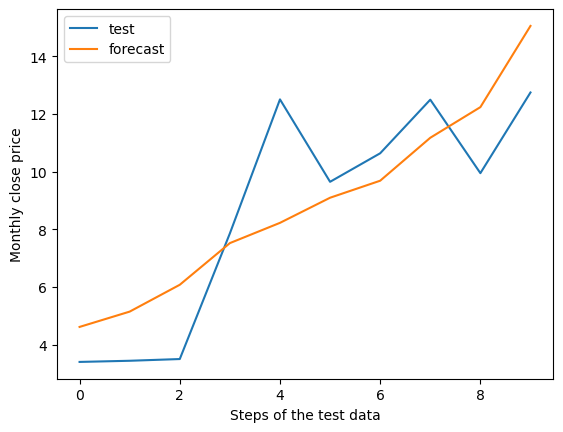

r2_score:  0.6812908272053729
rmse:  2.074467455744641
description:  count    115.000000
mean       1.406435
std        2.636445
min        0.200000
25%        0.250000
50%        0.470000
75%        0.610000
max       12.750000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=rtbriscoe_end_month_df['close_price'][:-10]
y_test=rtbriscoe_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(0,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', rtbriscoe_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=rtbriscoe_end_month_df['returns'].dropna()[:-10]
test=rtbriscoe_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.20515739914745468]
[0, 0, 0, 0, 0, 1, -0.23303852048868823]
[0, 0, 0, 0, 0, 2, -0.24788786626659554]
[0, 0, 0, 0, 1, 0, -0.1479011394558496]
[0, 0, 0, 0, 1, 1, 0.03658247068371434]
[0, 0, 0, 0, 1, 2, 0.03487010900956522]
[0, 0, 0, 0, 2, 0, -0.832597968749772]
[0, 0, 0, 0, 2, 1, -0.18238340036304979]
[0, 0, 0, 0, 2, 2, 0.2688761810127207]
[0, 0, 0, 1, 0, 0, -0.23074688935843035]
[0, 0, 0, 1, 0, 1, -0.29057790811668593]
[0, 0, 0, 1, 0, 2, -0.2625213047054198]
[0, 0, 0, 1, 1, 0, -0.2875169263693198]
[0, 0, 0, 1, 1, 1, 0.028193737312134814]
[0, 0, 0, 1, 1, 2, 0.014812175649063342]
[0, 0, 0, 1, 2, 0, -0.5075259033497492]
[0, 0, 0, 1, 2, 1, -0.2837043391162466]
[0, 0, 0, 1, 2, 2, 0.2397644380035715]
[0, 0, 0, 2, 0, 0, -0.22605181164979982]
[0, 0, 0, 2, 0, 1, -0.2559557858116108]
[0, 0, 0, 2, 0, 2, -0.2594365491101063]
[0, 0, 0, 2, 1, 0, -0.22412986012492198]
[0, 0, 0, 2, 1, 1, 0.03171621910139111]
[0, 0, 0, 2, 1, 2, 0.040121060793397056]
[0, 0, 0, 2, 2, 0, -4.0972446101

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-19353.291728
177,0,2,0,1,2,0,-6723.128091
169,0,2,0,0,2,1,-5890.937086
165,0,2,0,0,1,0,-4560.051723
186,0,2,0,2,2,0,-2499.242737
...,...,...,...,...,...,...,...
602,2,1,1,0,2,2,0.272524
116,0,1,1,0,2,2,0.275308
386,1,1,2,0,2,2,0.282858
98,0,1,0,1,2,2,0.303965


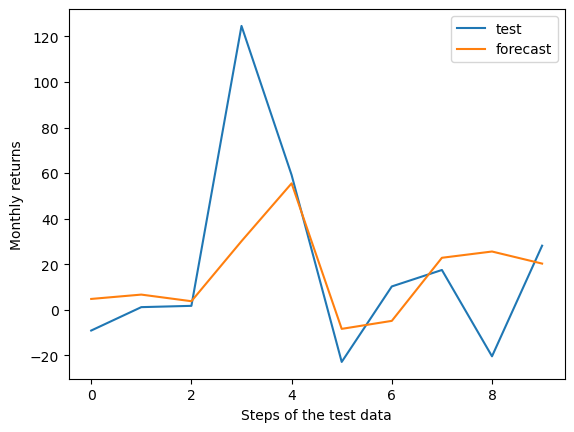

r2_score:  0.3304815953361825
rmse:  34.35612793699677
description:  count    114.000000
mean       7.799198
std       50.870496
min      -30.985915
25%       -4.743304
50%        0.000000
75%        0.000000
max      418.421053
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=rtbriscoe_end_month_df['returns'].dropna()[:-10]
y_test=rtbriscoe_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,1,0), 
seasonal_order=(0,2,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', rtbriscoe_end_month_df.returns.dropna().describe())

much better.